In [1]:
import warnings
warnings.filterwarnings('ignore') #, category=UserWarning)

import numpy as np
from vorothreshold import voronoi_threshold_finder
from vorothreshold.read_funcs import read_voronoi_vide
import matplotlib.pyplot as plt

The standard methodology to postprocess vide voids in boxes in order to find the corresponding threshold voids, requires two quantities, which are:

- A list/array or a single value of threshold. This should be passed as the value of the normalized density, i.e. 1+$\delta$

- The path of vide directory, the one containing all the outputs 

In addition, the `lightcone` input should be set to `False`:

In [2]:
thresholds = [0.2,0.3]
vide_path='/mnt/home/gverza/Desktop/Codes/Voronoi_postprocess/example/data/box/examples/example_simulation/sim_ss1.0/sample_sim_ss1.0_z0.00_d00/'
th_voids = voronoi_threshold_finder(thresholds,lightcone=False,vide_path=vide_path,verbose=True)

    Loading VIDE data.
    Lbox from VIDE: 999.983
        done: 0 h 0 min 3.665130615234375 sec.
    max_num_part < 0: authomatically set to 5 * max(num_part): 5220

    voronoi_threshold started. PBC on with Lbox: 999.983

    nthreads set to 32

    max_num_part set to 5220

    computation started

    get void properties, PBC on, Lbox: 999.983
    done, 0 h 0 min 11.960661172866821 sec. 

        main computation done: 0 h 0 min 12.044691801071167 sec.


To get threshold void properties, we use the `get_values` function from the `voronoi_threshold_finder` class. The arguments are the specific threshold value, among the values in `thresholds`, the quantity we want to obtain, and the overlapping fraction,`frac_ovlp`. This last quantity represents the maximum fractional amount of volume shared with an anther void. It is a free parameter, any value below or equal to 0.5 is fine. The corresponding output will contains voids which overlaps for a fraction of their volume minor or equal to `frac_ovlp`. The use of `frac_ovlp` is necessary to avoid double counting, as the thresholding procedure may merge adjacent basins in a unique void.

The ids of non-overlapping voids for a specific `frac_ovlp` is computed the first time that the value is passed to the `get_values` function. Alternatively, the ids can be computed by calling the `compute_overlaps` function, which accept as arguments both a single `frac_ovlp`, or multiple values passed as a list or a `numpy` array. In such a case, all the computations for all the combination `frac_ovlp` and `thresholds` values will be performed in parallel.

In [23]:
frac_ovlp_list = [0.5,0.25,0.]

th_voids.compute_overlaps(np.array(frac_ovlp_list),verbose=False)

print('keys:',th_voids.id_out.keys())
print('keys:',th_voids.id_out[0].keys())

keys: dict_keys([0, 1])
keys: dict_keys([0.5, 0.0, 0.25])


The following cell extract some threshold voids properties with `get_values`. The list of available options is the following: 

- Ncells: Number of Voronoi cells contained in each void. This is an array of float as the last Voronoi cell adds as the volume fraction considered to reach the threshold value. dtype=float64, shape=(N,)
        
- ID_original_sample: IDs of the void of the original VIDE catalog used to start the thresholding process. dtype=int64, shape=(N,)
            
- id_selected: IDs of voids of the entire voronoi_threshold output that reach the threshold value and satisfying the overlaps condition. dtype=int64, shape=(N,)

- id_wrt_all: IDs of voids of the entire voronoi_threshold output that reach the threshold value and satisfying the overlaps condition. dtype=int64, shape=(N,)

- xyz: Comoving coordinates of the volume weighted barycenter. dtype=float64, shape=(N,3)

- redshift: Redshift of the volume weighted barycenter. dtype=float64, shape=(N,)

- volume: Void volumes. dtype=float64, shape=(N,)

- radius: Void effective radius. dtype=float64, shape=(N,)

- ell_eigenvalues: eigenvalues of the inertial tensor. dtype=float64, shape=(N,3)

- ell_eigenvectors: eigenvectors of the inertial tensor. dtype=float64, shape=(N,3,3)

In [27]:
xyz = dict()
radius = dict()
for thr in thresholds:
    xyz[thr] = dict()
    radius[thr] = dict()
    for frac_ovlp in frac_ovlp_list:
        #z_voids[thr] = dict()
        xyz[thr][frac_ovlp] = th_voids.get_values(thr,'xyz',frac_ovlp)
        radius[thr][frac_ovlp] = th_voids.get_values(thr,'radius',frac_ovlp)
        #z_voids[thr][frac_ovlp] = th_voids.get_values(thr,'redshift',frac_ovlp)
        #print(xyz[thr][frac_ovlp].shape,radius[thr][frac_ovlp].shape,z_voids[thr][frac_ovlp].shape)

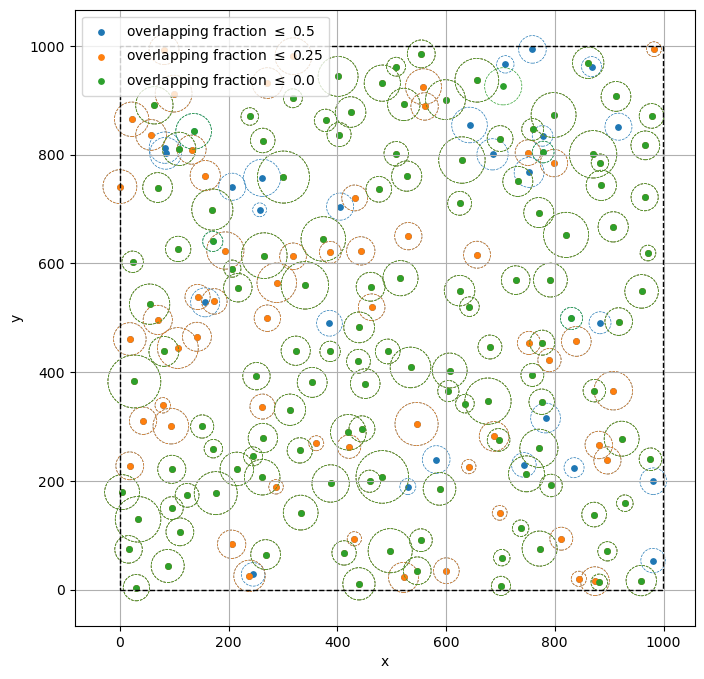

In [28]:
import matplotlib
fig = plt.figure(figsize=(8,8))
ax0 = plt.subplot2grid((1,1), (0,0), rowspan=1, colspan=1)
#ax0 = plt.subplot2grid((1,2), (0,1), rowspan=1, colspan=1)
#ax1 = plt.subplot2grid((1,2), (0,0), rowspan=1, colspan=1)
from vorothreshold.read_funcs import load_pickle_safe
Lbox = load_pickle_safe(vide_path+'/sample_info.dat')['boxLen']
progr = 0
for frac_ovlp in frac_ovlp_list:
    cc = plt.cm.tab10(progr)
    mask = xyz[thr][frac_ovlp][:,2] < 100.
    patches = []
    CC = []
    for i in range(np.sum(mask)):
        # circle centered in #RAcm[i],DECcm[i] with radius dist_ang_max[i] * 180 / np.pi
        patches.append(plt.Circle((xyz[thr][frac_ovlp][mask,0][i], xyz[thr][frac_ovlp][mask,1][i]), radius[thr][frac_ovlp][mask][i]))
        CC.append(cc)
    coll = matplotlib.collections.PatchCollection(patches,facecolors='None',linestyle='--',linewidth=0.5,edgecolor=CC)
    ax0.scatter(xyz[thr][frac_ovlp][mask,0],xyz[thr][frac_ovlp][mask,1],s=15,label='overlapping fraction $\leq$ '+str(frac_ovlp))
    ax0.add_collection(coll)
    progr += 1
ax0.axis('equal')
ax0.set_xlabel('x')
ax0.set_ylabel('y')
ax0.grid()
ax0.plot([0,Lbox,Lbox,0,0],[0,0,Lbox,Lbox,0],c='k',lw=1,ls='--')
plt.legend()

In [26]:
max_voro_in_voids = np.max(th_voids.get_values(np.max(thresholds),'Ncells',1.))
max_voro_in_voids = int(max_voro_in_voids) + int(max_voro_in_voids%1 > 0)
print('max_num_part passed:',th_voids.max_num_part,'max num of voronoi in one void:',max_voro_in_voids,
      'Nvds with num max:',np.sum(th_voids.get_values(np.max(thresholds),'Ncells',1.)==max_voro_in_voids))

max_num_part passed: 5220 max num of voronoi in one void: 138 Nvds with num max: 0


In [8]:
xyz = dict()
radius = dict()
z_voids = dict()
frac_ovlp = 0.5
for thr in thresholds:
    xyz[thr] = dict()
    radius[thr] = dict()
    z_voids[thr] = dict()
    xyz[thr][frac_ovlp] = th_voids.get_values(thr,'xyz',frac_ovlp)
    radius[thr][frac_ovlp] = th_voids.get_values(thr,'radius',frac_ovlp)
    z_voids[thr][frac_ovlp] = th_voids.get_values(thr,'redshift',frac_ovlp)
    #print(xyz[thr][frac_ovlp].shape,radius[thr][frac_ovlp].shape,z_voids[thr][frac_ovlp].shape)

Plot of the spatial distribution of threshold voids. Since the original galaxy sample is small, many threshold voids has Voronoi cells touching borders.

Plot of the spatial distribution of Voronoi cells belonging to threshold voids with respect to the full galaxy distribution.

In [32]:

from scipy.interpolate import CubicSpline
def void_contour_2D(xyz_center,xyz_gal_in_vd,nbins=-1,npts_plot=-1,ij=(0,1)):
    # xyz_center: void center position
    # xyz_gal_in_vd: positions of galaxies in void
    # nbins: number of bins for interpolation. If nbins < 1 it will be automatically computed.
    # npts_plot: length of the ounput arrays. If npts_plot < 1 it will be automatically computed.
    # ij: projection axis, default value are (0,1), corresponding to the (x,y) plane

    if nbins < 1:
        nbins = max(10,int(len(xyz_gal_in_vd) ** 0.5))
    if npts_plot < 1:
        npts_plot = nbins * 5
    delta_xyz = xyz_gal_in_vd - xyz_center
    dist_gal_proj = np.sqrt(np.sum(np.square(delta_xyz[:,ij]),axis=1))
    
    phi = np.sign(delta_xyz[:,ij[1]]) * np.arccos(delta_xyz[:,ij[0]] / dist_gal_proj)

    phi_bin = np.linspace(-np.pi,np.pi,nbins)

    id_trs = np.arange(phi.shape[0])

    idx_surface = np.empty(phi_bin.shape[0]-1,dtype=np.int_)
    idx_surface[:] = -1
    for iphi in range(phi_bin.shape[0]-1):
        mask = (phi >= phi_bin[iphi]) & (phi < phi_bin[iphi+1])
        try:
            idx_surface[iphi] = id_trs[mask][np.argmax(dist_gal_proj[mask])]
        except:
            pass
    idx_surface = idx_surface[idx_surface>-1]

    idx_surface_inerp = np.append(idx_surface,idx_surface[[0]])
    phi_interp = np.append(phi[idx_surface],phi[idx_surface][[0]]+2*np.pi)

    dist_interp = dist_gal_proj[idx_surface_inerp]
    interp = CubicSpline(phi_interp,dist_interp,bc_type='periodic')
    phi_plot = np.linspace(-np.pi,np.pi,101)

    return xyz_center[0]+np.cos(phi_plot)*interp(phi_plot),xyz_center[1]+np.sin(phi_plot)*interp(phi_plot)

(1281,) (1281,) True


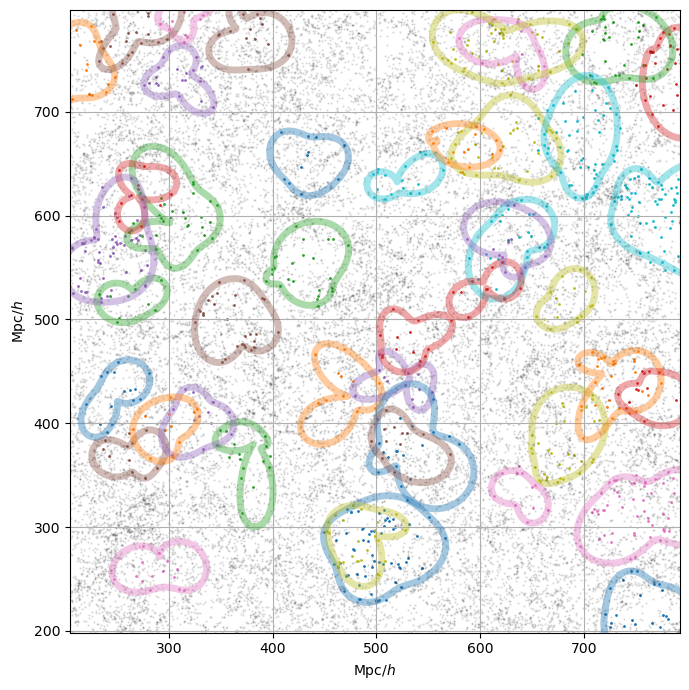

In [99]:
# select slab:
ids_voro, VoroVol, VoroXYZ, RA, Dec, redshift = read_voronoi_vide(vide_path)

xyz_ref = np.mean(VoroXYZ,axis=0) # the slab center has been chose as the mean galaxy position. It can be substituted with any value
x_thick = 300. # half-plane extension in the x direction
y_thick = 300. # half-plane extension in the y direction
z_thick = 100.  # half thickness of the projection along the z direction

# select galaxies in the slab
mask_gal = (VoroXYZ[:,0] >= xyz_ref[0] - x_thick) & (VoroXYZ[:,0] <= xyz_ref[0] + x_thick) & \
           (VoroXYZ[:,1] >= xyz_ref[1] - y_thick) & (VoroXYZ[:,1] <= xyz_ref[1] + y_thick) & \
           (VoroXYZ[:,2] >= xyz_ref[2] - z_thick) & (VoroXYZ[:,2] <= xyz_ref[2] + z_thick)

ith = len(thresholds)-1
thr = thresholds[ith]
#id_selected = np.arange(th_voids.Xcm.shape[0])[th_voids.Ncells_in_void[:,0] > 10]
id_ovlp_out = th_voids.get_values(thr,'id_wrt_all',frac_ovlp)
id_wrt_all = th_voids.get_values(thr,'id_selected',frac_ovlp)
print(id_ovlp_out.shape,id_wrt_all.shape,np.all(id_wrt_all==id_ovlp_out))
# select voids with their center in the slab
voids_xyz = th_voids.Xcm[:,ith,:] #th_voids.get_values(thr,'xyz',frac_ovlp)
mask_voids = np.zeros(voids_xyz.shape[0],dtype=np.bool_)
mask_voids[id_ovlp_out] = True
mask_voids &= (voids_xyz[:,0] >= xyz_ref[0] - x_thick) & (voids_xyz[:,0] <= xyz_ref[0] + x_thick) & \
             (voids_xyz[:,1] >= xyz_ref[1] - y_thick) & (voids_xyz[:,1] <= xyz_ref[1] + y_thick) & \
             (voids_xyz[:,2] >= xyz_ref[2] - z_thick) & (voids_xyz[:,2] <= xyz_ref[2] + z_thick)
voids_xyz = th_voids.Xcm[mask_voids,ith,:]
id_ovlp_out = np.arange(mask_voids.shape[0])[mask_voids]
id_progr = np.arange(mask_voids.shape[0])[mask_voids]
#ids_voids = id_ovlp_out[mask_voids]
fig = plt.figure(figsize=[7,7])
cprogr = 0
for iprogr in range(np.sum(mask_voids)):
    ii = id_ovlp_out[iprogr]
    # select galaxies both in voids and in the slab
    #print(ii,th_voids.Ncells_in_void[ii,ith])
    ids_in_voids = th_voids.ID_voro_dict[ii][:int(th_voids.Ncells_in_void[ii,ith]+1)]
    xyz_test = th_voids.Xcm[ii,ith,:]
    mask_gal_loop = (VoroXYZ[ids_in_voids,0] >= xyz_ref[0] - x_thick) & (VoroXYZ[ids_in_voids,0] <= xyz_ref[0] + x_thick) & \
                    (VoroXYZ[ids_in_voids,1] >= xyz_ref[1] - y_thick) & (VoroXYZ[ids_in_voids,1] <= xyz_ref[1] + y_thick) & \
                    (VoroXYZ[ids_in_voids,2] >= xyz_ref[2] - z_thick) & (VoroXYZ[ids_in_voids,2] <= xyz_ref[2] + z_thick)
    if int(th_voids.Ncells_in_void[ii,ith]+1) < 10:
        continue
    mask_gal[ids_in_voids] = False # remove from the general selection galaxies that are both in voids and in the slab
    
    # plot void contour and galaxies within it with the same color#
    #scat = plt.scatter(VoroXYZ[ids_in_voids[mask_gal_loop],0],VoroXYZ[ids_in_voids[mask_gal_loop],1],s=1)
    cprogr +=  cprogr == 7
    cc = plt.cm.tab10(cprogr)
    scat = plt.scatter(VoroXYZ[ids_in_voids,0],VoroXYZ[ids_in_voids,1],s=1,color=cc)
    #plt.scatter(voids_xyz[iprogr,0],voids_xyz[iprogr,1],c=scat.get_facecolors(),alpha=1)
    #plt.scatter(xyz_test[0],xyz_test[1],c=scat.get_facecolors(),s=5)
     
    plt.plot(*void_contour_2D(voids_xyz[iprogr,:],VoroXYZ[ids_in_voids,:]),lw=5,alpha=0.4,c=scat.get_facecolors())
    cprogr = (cprogr+1)%10

# plot galaxies within the slab but not belonging to selected voids in black
plt.scatter(VoroXYZ[mask_gal,0],VoroXYZ[mask_gal,1],s=0.5,c='k',alpha=0.1)
plt.axis('equal')
plt.xlabel('Mpc/$h$')
plt.ylabel('Mpc/$h$')
plt.grid()
fig.tight_layout()
plt.xlim(xyz_ref[0] - x_thick*0.9,xyz_ref[0] + x_thick*0.9)
plt.ylim(xyz_ref[1] - y_thick,xyz_ref[1] + y_thick)

plt.savefig('void_contours_slab_v2.png')

(array([992., 617., 269., 118.,  84.,  49.,  21.,  17.,  16.,   7.,   7.,
          6.,   6.,   1.,   1.,   3.,   1.,   1.,   1.,   2.]),
 array([  1.00429201,   7.84925288,  14.69421375,  21.53917462,
         28.38413549,  35.22909636,  42.07405723,  48.9190181 ,
         55.76397897,  62.60893984,  69.45390071,  76.29886158,
         83.14382245,  89.98878332,  96.83374419, 103.67870506,
        110.52366593, 117.3686268 , 124.21358767, 131.05854854,
        137.90350941]),
 <BarContainer object of 20 artists>)

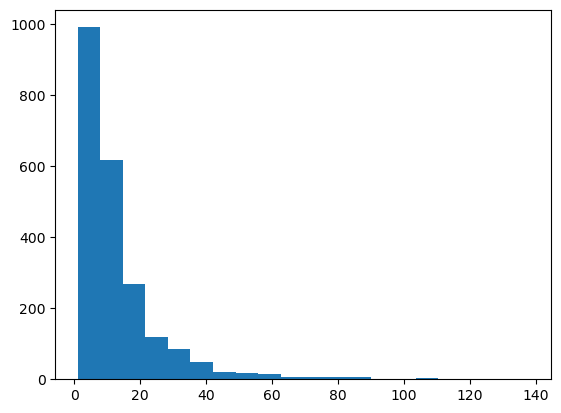

In [74]:
plt.hist(th_voids.Ncells_in_void[:,ith],bins=20)

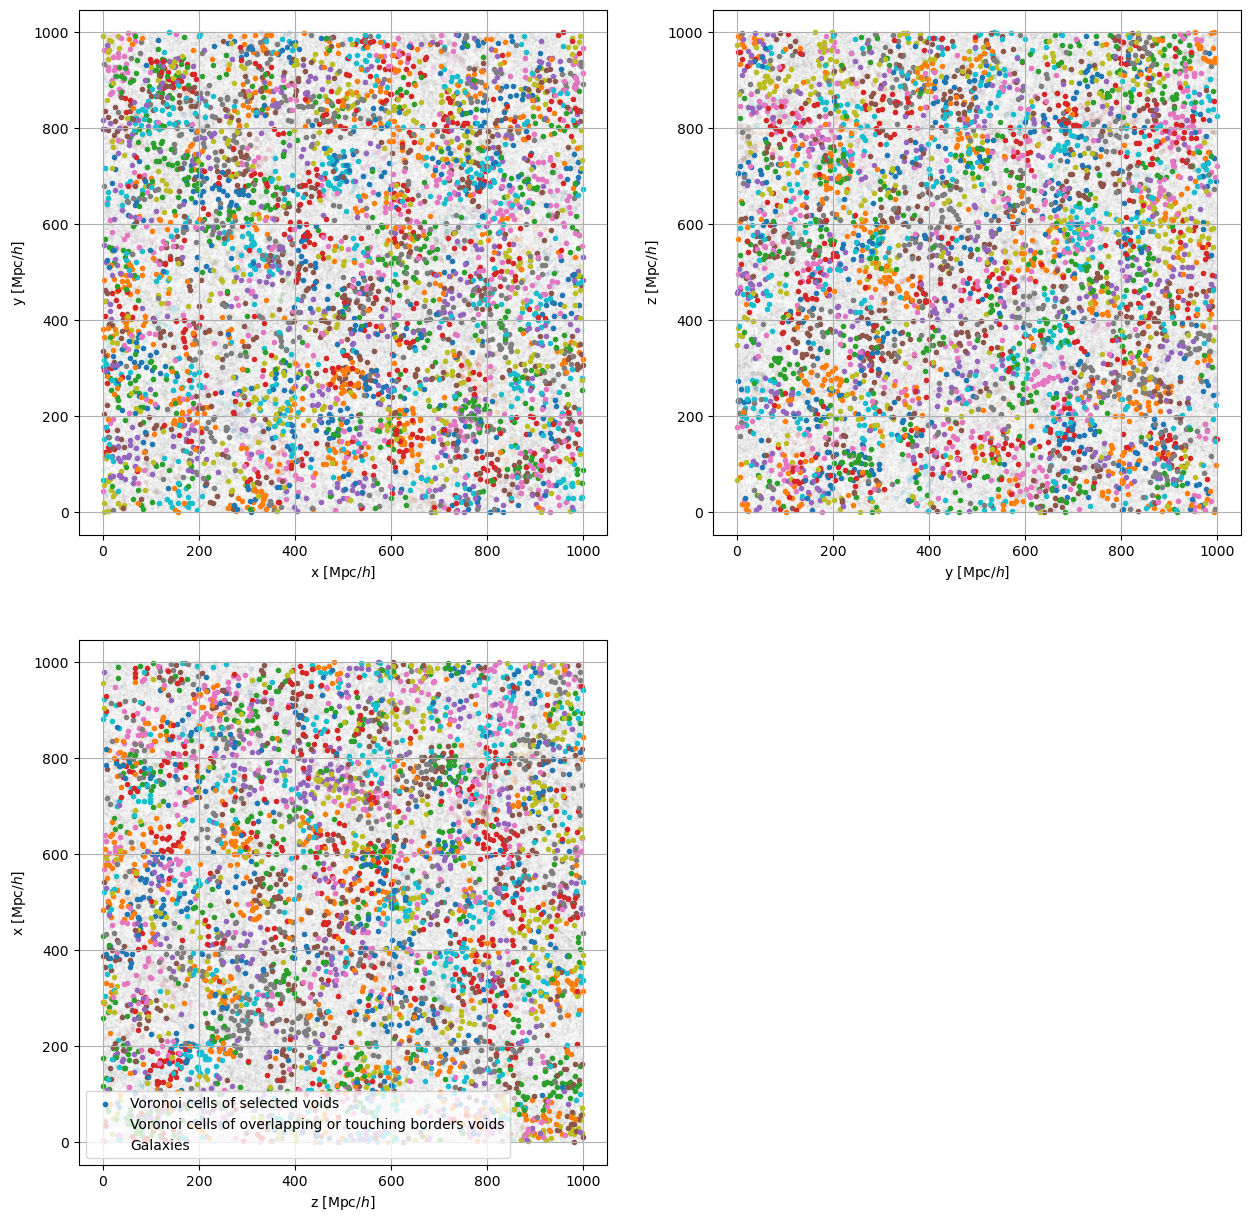

In [31]:
#from vorothreshold.read_funcs import read_voronoi_vide
#asd = voro_in_vide_voids('data/lightcone/examples/example_observation/sample_example_observation/','example_observation')
ids_voro, VoroVol, VoroXYZ, RA, Dec, redshift = read_voronoi_vide(vide_path)
id_selected = np.arange(th_voids.Xcm.shape[0])[th_voids.Ncells_in_void[:,0] > 10]
id_ovlp_out = th_voids.get_values(thr,'id_selected',frac_ovlp)
fig = plt.figure(figsize=(15,15))
ax = dict()
for i in range(3):
    ax[i] = plt.subplot2grid((2,2), (int(i/2),i%2), rowspan=1, colspan=1)
    ax[i].scatter(VoroXYZ[:,i%3],VoroXYZ[:,(i+1)%3],s=0.1,alpha=0.02,c='k')
progr = 0
for id in id_selected:
    Xcm_interp = th_voids.Xcm[id,ith,:]
    IDthresholds = th_voids.ID_voro_dict[id][:int(th_voids.Ncells_in_void[id,0]+1)]
    alpha = 0.1
    for i in range(3):
        ax[i].scatter(VoroXYZ[IDthresholds,i%3],VoroXYZ[IDthresholds,(i+1)%3],s=9,alpha=0.1)
            #ax[i].scatter(Xcm_interp[i%3],Xcm_interp[(i+1)%3])
        #ax[i].scatter(core_pos[iv,i%3],core_pos[iv,(i+1)%3],c='r',)
        #ax[i].scatter(barycenter[iv,i%3],barycenter[iv,(i+1)%3],c='m')
    progr +=1
progr = 0
for id in id_ovlp_out:
    Xcm_interp = th_voids.Xcm[id,ith,:]
    IDthresholds = th_voids.ID_voro_dict[id][:int(th_voids.Ncells_in_void[id,0]+1)]
    
    for i in range(3):
        ax[i].scatter(VoroXYZ[IDthresholds,i%3],VoroXYZ[IDthresholds,(i+1)%3],s=9,alpha=1.)
            #ax[i].scatter(Xcm_interp[i%3],Xcm_interp[(i+1)%3])
        #ax[i].scatter(core_pos[iv,i%3],core_pos[iv,(i+1)%3],c='r',)
        #ax[i].scatter(barycenter[iv,i%3],barycenter[iv,(i+1)%3],c='m')
    progr +=1
for i in range(3):
    ax[i].axis('equal')
    ax[i].set_xlabel(['x','y','z'][i%3]+' [Mpc/$h$]')
    ax[i].set_ylabel(['x','y','z'][(i+1)%3]+' [Mpc/$h$]')
    ax[i].grid()
ax[2].scatter(np.nan,np.nan,s=9,alpha=1.,label='Voronoi cells of selected voids')
ax[2].scatter(np.nan,np.nan,s=9,alpha=0.1,label='Voronoi cells of overlapping or touching borders voids')
ax[2].scatter(np.nan,np.nan,s=0.1,alpha=0.02,c='k',label='Galaxies')
ax[2].legend()